In [2]:
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, LinearLocator,AutoMinorLocator
from matplotlib import rcParams
rcParams["font.size"]=14
import h5py
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
import matplotlib.font_manager as fm
import imageio
import pynbody.plot.sph as sph
from astropy import units as u
from matplotlib.colors import LogNorm
import pynbody
import seaborn as sns
from read_binary_snap import read

## USEFUL FUNCTIONS

In [3]:
def create_df(path):
    header, data, info = read(path, header_only = False, IC_only = False, control = False)
    print(header["time"]*9.8)
    Stellar_Age = (header["time"]  - data["PartType4"]["StellarFormationTime"])*9.8
    Stellar_Ab = data["PartType4"]["ElementAbundance"]*1e10
    Fe_H, O_Fe = metallicity(Stellar_Ab)
    data_dict = pd.DataFrame({"Age": Stellar_Age,
                              "Fe_H": Fe_H,
                              "O_Fe": O_Fe,
                              "Mass": data["PartType4"]["Mass"].flatten()*1e10,
                              "SFT": data["PartType4"]["StellarFormationTime"]*9.8
                             })
    data_dict = data_dict.query("not (Fe_H < -2.2 & O_Fe > 0.12 & O_Fe < 0.13)")
    data_dict = data_dict.query("(Fe_H > -3.5) & (O_Fe > -1)")
    return data_dict

#ABUNDANCES ORDER:  He, C, Mg, O, Fe, Si, H, N, Ne, S, Co, Zi
def metallicity(abundance):
    at_Fe = 56
    at_O = 16
    FeH_sun = (7.45 - 12)  ### FROM https://arxiv.org/pdf/1912.00844
    OFe_sun = (8.73 - 7.45) ### FROM https://arxiv.org/pdf/1912.00844

    Fe= abundance[:,4]
    O= abundance[:,3]
    H= abundance[:,6]
    Fe_H = np.log10((Fe/at_Fe)/H) - FeH_sun
    O_Fe = np.log10((O/at_O)/(Fe/at_Fe)) - OFe_sun
    return Fe_H, O_Fe


def func_bar(x, y, edges, mass=[], reduce_func=np.sum, cumulative=False, ascending=True, n_bin = False):
    """
    Function to bin and summarize data based on specified edges and reduce_func.

    Args:
        x: Data points along the x-axis.
        y: Data points along the y-axis.
        edges: Specifies the edges of the bins.
        mass: Optional; an array representing the mass associated with each data point. Default is an empty list.
        reduce_func: Optional; a function used to summarize the data within each bin. Default is np.sum.
        cumulative: Optional boolean; determines whether the function should calculate cumulative values. Default is False.
        ascending: Optional boolean; determines the order of the x-axis values, relevant only cumulative = True. Default is True.

    Returns:
        r_mean: Array of mean bins.
        y_val: Array of summarized y-values.
        y_mass: Array of summarized mass if mass is provided, otherwise empty array.
    """
    # Initialize lists to store calculated values
    y_mass = []
    y_val = []
    r_mean = []
    masked_data = []
    if n_bin:
         nbin_list = []
    # Iterate over the range of edges, processing each bin
    for i in range(len(edges) - 1):
        if ascending:
            # Return x-axis values in ascending order (relevant if cumulative=True)
            mask = (x >= edges[i]) & (x < edges[i + 1])
            mean_bins = (edges[i] + edges[i + 1]) / 2
        else:
            # Return x-axis values in descending order (relevant if cumulative=True)
            mask = (x >= edges[len(edges) - i - 2]) & (x < edges[len(edges) - i - 1])
            mean_bins = (edges[len(edges) - i - 2] + edges[len(edges) - i - 1]) / 2

        if not cumulative:
            masked_data = y[mask]
            if len(mass) > 0:
                masked_mass = mass[mask]
        if cumulative:
            masked_data = np.array(list(masked_data) + list(y[mask]))
            if len(mass) > 0:
                masked_mass = np.array(list(masked_mass) + list(mass[mask]))

        if n_bin:
            nbin_list.append(len(masked_data))
        bin_y = reduce_func(masked_data)

        # Append calculated values to respective lists
        y_val.append(bin_y)
        r_mean.append(mean_bins)
        if len(mass) > 0:
            y_mass.append(np.sum(masked_mass))

    # Return arrays of mean bins, summarized y-values, and summarized mass if provided
    if len(mass) > 0:
        return np.array(r_mean), np.array(y_val), np.array(y_mass)
    if n_bin:
        return np.array(r_mean), np.array(y_val), np.array(nbin_list)
    return np.array(r_mean), np.array(y_val)


#Bins equally spaced, received
def uni_bins(data, bins): #->return edges
    edges = np.histogram_bin_edges(data, bins)
    edges[-1] = edges[-1] + 0.1
    return np.array(edges)

def get_percentile(data):
    if len(data) > 0:
        return np.percentile(data, 25, axis = 0), np.nanpercentile(data, 75, axis = 0)
    else:
        return np.nan, np.nan


## PARTE 1

11.622799970209599
11.622799970209599


/tmp/ipykernel_2792189/698583637.py:27: RuntimeWarning: divide by zero encountered in log10
  Fe_H = np.log10((Fe/at_Fe)/H) - FeH_sun
/tmp/ipykernel_2792189/698583637.py:28: RuntimeWarning: invalid value encountered in divide
  O_Fe = np.log10((O/at_O)/(Fe/at_Fe)) - OFe_sun
/tmp/ipykernel_2792189/698583637.py:27: RuntimeWarning: divide by zero encountered in log10
  Fe_H = np.log10((Fe/at_Fe)/H) - FeH_sun
/tmp/ipykernel_2792189/698583637.py:28: RuntimeWarning: invalid value encountered in divide
  O_Fe = np.log10((O/at_O)/(Fe/at_Fe)) - OFe_sun


11.622799970209599
11.622799970209599


/tmp/ipykernel_2792189/698583637.py:27: RuntimeWarning: divide by zero encountered in log10
  Fe_H = np.log10((Fe/at_Fe)/H) - FeH_sun
/tmp/ipykernel_2792189/698583637.py:28: RuntimeWarning: invalid value encountered in divide
  O_Fe = np.log10((O/at_O)/(Fe/at_Fe)) - OFe_sun
/tmp/ipykernel_2792189/698583637.py:27: RuntimeWarning: divide by zero encountered in log10
  Fe_H = np.log10((Fe/at_Fe)/H) - FeH_sun
/tmp/ipykernel_2792189/698583637.py:28: RuntimeWarning: invalid value encountered in divide
  O_Fe = np.log10((O/at_O)/(Fe/at_Fe)) - OFe_sun


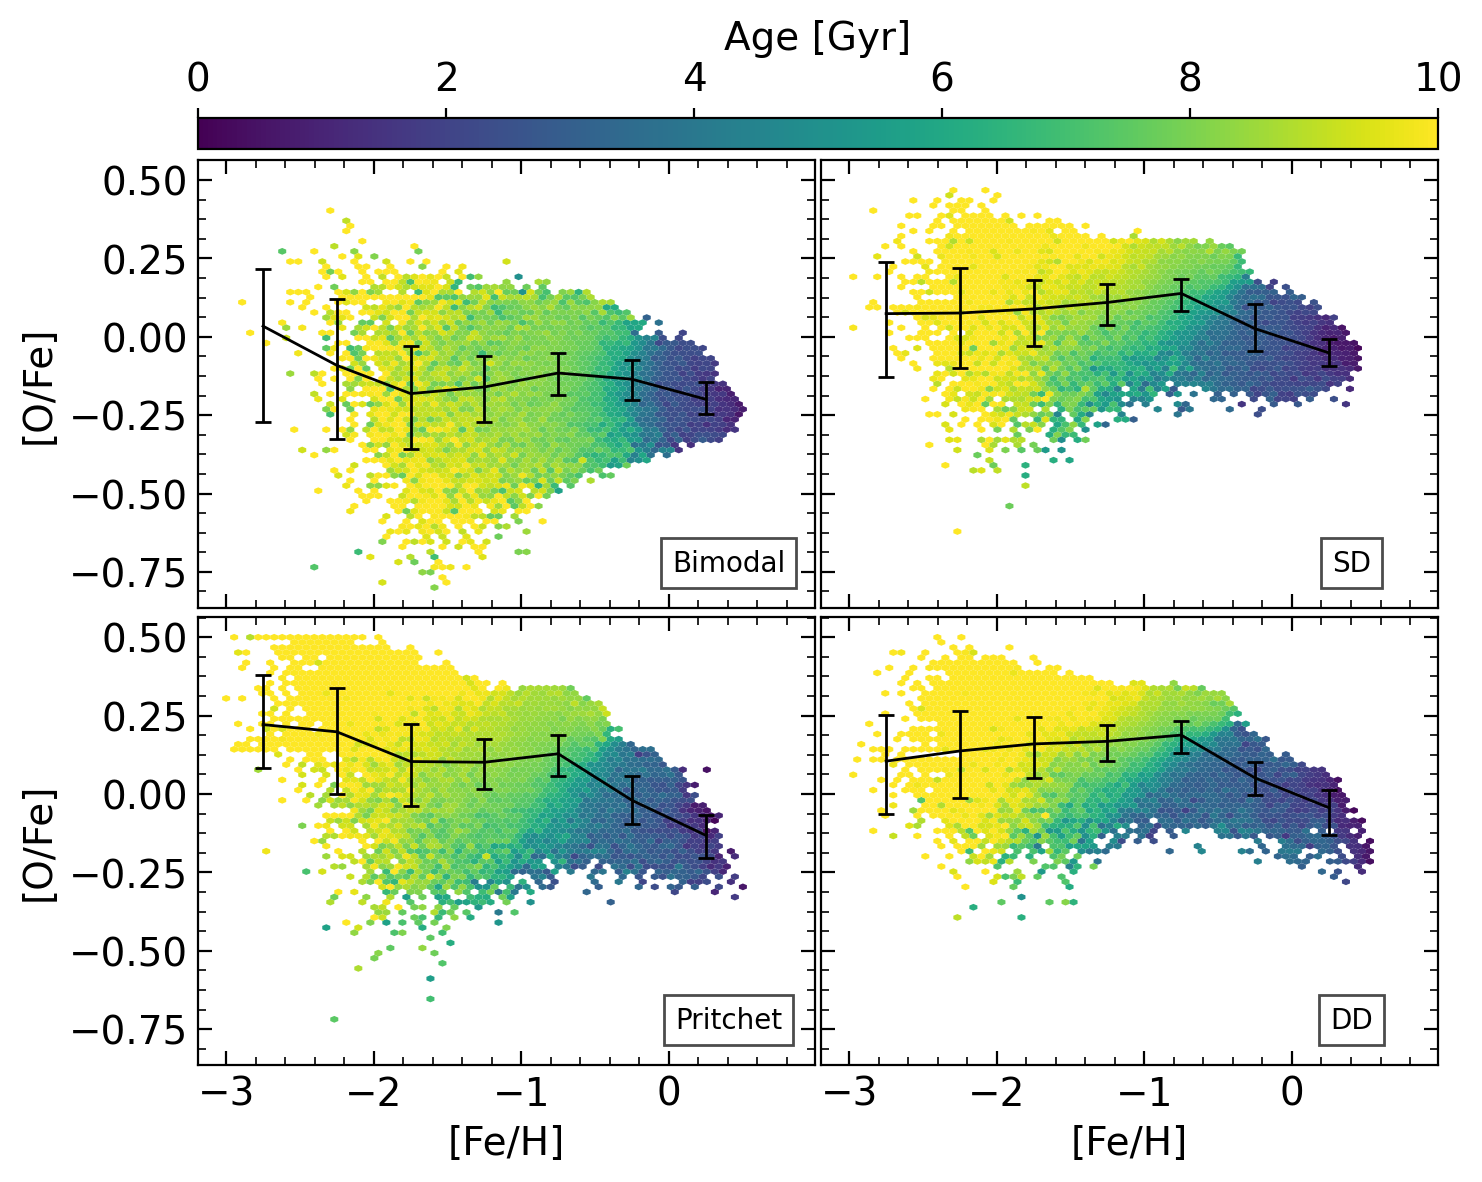

In [4]:
paths_pt1 = glob.glob('/home/amanda.ormazbal/gadget4/examples/CollidingGalaxiesSFR/output/Project3_snaps/*237')

fig, ax = plt.subplots(2, 2, figsize=(8,7), dpi=200, sharey = True,sharex = True,
                      gridspec_kw = {"wspace":0.01, "hspace":0.02})
ax = np.ravel(ax)
extent = [-3,0.8,-0.8,0.5]

for i in range(len(paths_pt1)):
    model_label = paths_pt1[i].split("/")[-1].split("_")[0]
    df = create_df(paths_pt1[i])
    
    pc = ax[i].hexbin(df["Fe_H"], df["O_Fe"], C = df["Age"], ec = None, cmap = "viridis", gridsize = 70,
                mincnt = 4, extent = extent, vmin = 0, vmax = 10)



    edges = np.arange(-3, 1, 0.5)#uni_bins(df["Fe_H"], 10)#np.arange(7.2, 11.3, 1)
    x, y = func_bar(df["Fe_H"] , df["O_Fe"] , edges, reduce_func = np.median)
    x, p = func_bar(df["Fe_H"] , df["O_Fe"] , edges, reduce_func = get_percentile)
    
    p[:,0], p[:,1] = y - p[:,0], abs(y - p[:,1])
    ax[i].errorbar(x, y, yerr = p.T, capsize = 3, c = "k", label = model_label, zorder = 5, lw = 1)

    ax[i].tick_params(bottom = True, top = True, left = True, right = True, direction = 'in', size = 5)
    ax[i].tick_params(which ="minor",bottom = True, top = True, left = True, right = True, direction = 'in', size = 3)
    
    ax[i].xaxis.set_major_locator(MultipleLocator(1))
    ax[i].xaxis.set_minor_locator(MultipleLocator(1/5))
    ax[i].yaxis.set_major_locator(MultipleLocator(0.25))
    ax[i].yaxis.set_minor_locator(MultipleLocator(0.25/4))
    #ax[i].set_ylim(-0.6, 0.5)
    
    ax[i].text(0.86, 0.1, f'{model_label}', fontsize=10, color='black',
             transform=ax[i].transAxes, ha='center', va='center',bbox=dict(facecolor='white', alpha=0.7))
    if i > 1:
        ax[i].set_xlabel("[Fe/H]")
    if i%2 == 0:
        ax[i].set_ylabel("[O/Fe]")
        
cb = fig.colorbar(pc, ax = ax, label = "Age [Gyr]", location = "top", pad = 0.01,
                 aspect = 40)

11.622799970209599
11.622799970209599
11.622799970209599
11.622799970209599


/tmp/ipykernel_2792189/698583637.py:27: RuntimeWarning: divide by zero encountered in log10
  Fe_H = np.log10((Fe/at_Fe)/H) - FeH_sun
/tmp/ipykernel_2792189/698583637.py:28: RuntimeWarning: invalid value encountered in divide
  O_Fe = np.log10((O/at_O)/(Fe/at_Fe)) - OFe_sun
/tmp/ipykernel_2792189/698583637.py:27: RuntimeWarning: divide by zero encountered in log10
  Fe_H = np.log10((Fe/at_Fe)/H) - FeH_sun
/tmp/ipykernel_2792189/698583637.py:28: RuntimeWarning: invalid value encountered in divide
  O_Fe = np.log10((O/at_O)/(Fe/at_Fe)) - OFe_sun
/tmp/ipykernel_2792189/698583637.py:27: RuntimeWarning: divide by zero encountered in log10
  Fe_H = np.log10((Fe/at_Fe)/H) - FeH_sun
/tmp/ipykernel_2792189/698583637.py:28: RuntimeWarning: invalid value encountered in divide
  O_Fe = np.log10((O/at_O)/(Fe/at_Fe)) - OFe_sun
/tmp/ipykernel_2792189/698583637.py:27: RuntimeWarning: divide by zero encountered in log10
  Fe_H = np.log10((Fe/at_Fe)/H) - FeH_sun
/tmp/ipykernel_2792189/698583637.py:28: R

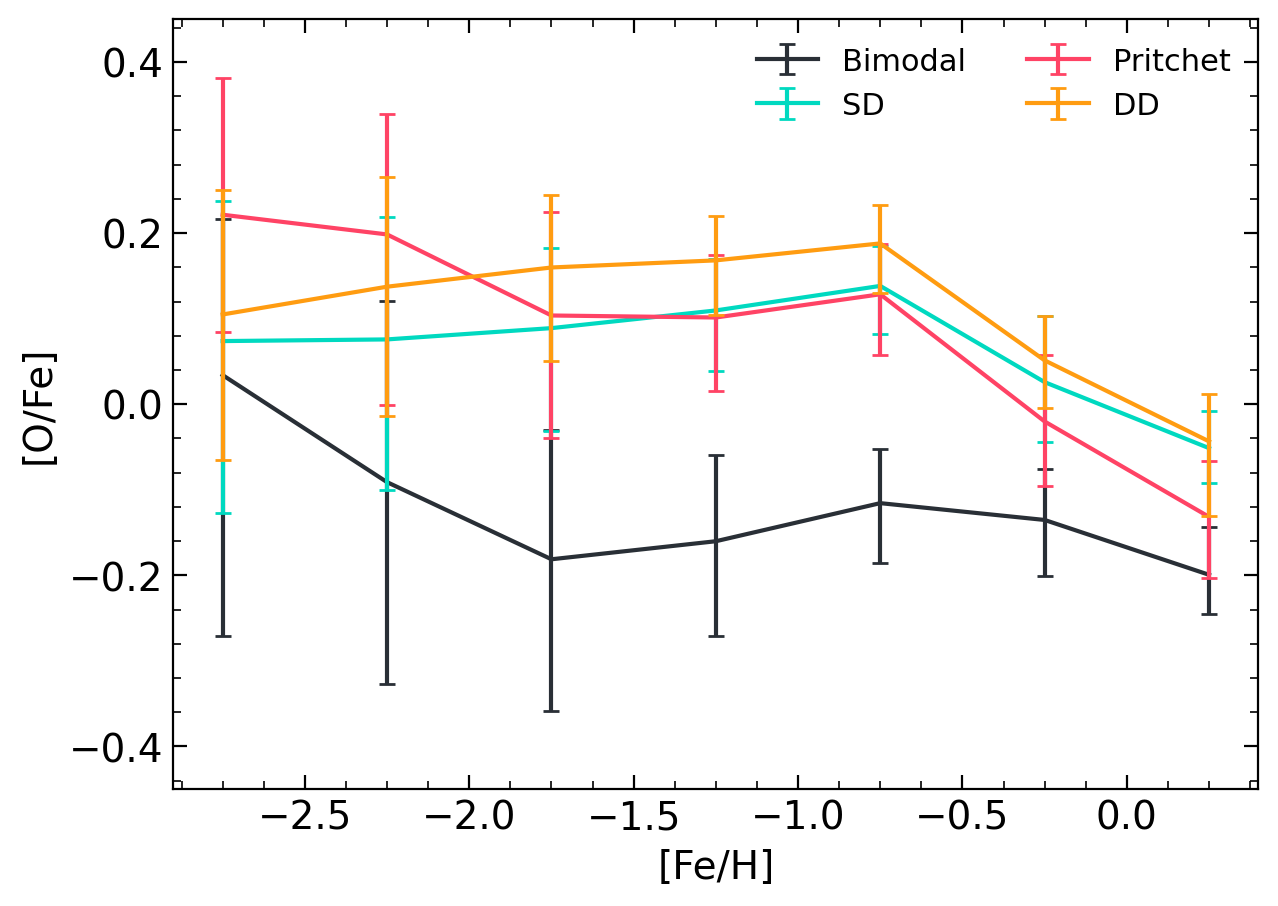

In [5]:
paths_pt1 = glob.glob('/home/amanda.ormazbal/gadget4/examples/CollidingGalaxiesSFR/output/Project3_snaps/*237')

fig, ax = plt.subplots(1, 1, figsize=(7, 5), dpi=200, sharey = True,sharex = True,
                      gridspec_kw = {"wspace":0, "hspace":0})

extent = [-3,0.8,-0.8,0.5]
colors =["#292F36", "#00D9C0", "#FF4365", "#FF9C11"]
for i in range(len(paths_pt1)):
    model_label = paths_pt1[i].split("/")[-1].split("_")[0]
    df = create_df(paths_pt1[i])

    #bensby = pd.DataFrame(np.loadtxt('Bensby+14.txt'), columns = ["HIP", "Mass", "Age", "Fe_H", "O_Fe"])
    #ax.scatter(bensby["Fe_H"], bensby["O_Fe"])
    
    edges = np.arange(-3, 1, 0.5)#uni_bins(df["Fe_H"], 10)#np.arange(7.2, 11.3, 1)
    x, y = func_bar(df["Fe_H"] , df["O_Fe"] , edges, reduce_func = np.median)
    x, p = func_bar(df["Fe_H"] , df["O_Fe"] , edges, reduce_func = get_percentile)
    
    p[:,0], p[:,1] = y - p[:,0], abs(y - p[:,1])
    ax.errorbar(x, y, yerr = p.T, capsize = 3, c = colors[i], label = model_label, zorder = i)

    legend_1 = ax.legend(fontsize = 11, loc='upper right', framealpha = 1, ncol = 2, edgecolor = "none")


    ax.tick_params(bottom = True, top = True, left = True, right = True, direction = 'in', size = 5)
    ax.tick_params(which ="minor",bottom = True, top = True, left = True, right = True, direction = 'in', size = 3)
    
    ax.xaxis.set_major_locator(MultipleLocator(0.5))
    ax.xaxis.set_minor_locator(MultipleLocator(0.5/4))
    ax.yaxis.set_major_locator(MultipleLocator(0.2))
    ax.yaxis.set_minor_locator(MultipleLocator(0.2/5))

    ax.set_xlabel("[Fe/H]")
    ax.set_ylabel("[O/Fe]")

    ax.set_ylim(-0.45, 0.45)

## PARTE 2

In [6]:
paths_pt2 = glob.glob('/home/amanda.ormazbal/gadget4/examples/CollidingGalaxiesSFR/output/Project3_snaps/*146')
paths_pt2

['/home/amanda.ormazbal/gadget4/examples/CollidingGalaxiesSFR/output/Project3_snaps/DD_HighC_snap_146',
 '/home/amanda.ormazbal/gadget4/examples/CollidingGalaxiesSFR/output/Project3_snaps/DD_snap_146']

7.1637999877333645
7.1637999877333645


/tmp/ipykernel_2792189/698583637.py:27: RuntimeWarning: divide by zero encountered in log10
  Fe_H = np.log10((Fe/at_Fe)/H) - FeH_sun
/tmp/ipykernel_2792189/698583637.py:28: RuntimeWarning: invalid value encountered in divide
  O_Fe = np.log10((O/at_O)/(Fe/at_Fe)) - OFe_sun
/usr/local/python-3.11.4/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/python-3.11.4/lib/python3.11/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)
/tmp/ipykernel_2792189/698583637.py:27: RuntimeWarning: divide by zero encountered in log10
  Fe_H = np.log10((Fe/at_Fe)/H) - FeH_sun
/tmp/ipykernel_2792189/698583637.py:28: RuntimeWarning: invalid value encountered in divide
  O_Fe = np.log10((O/at_O)/(Fe/at_Fe)) - OFe_sun
/usr/local/python-3.11.4/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mea

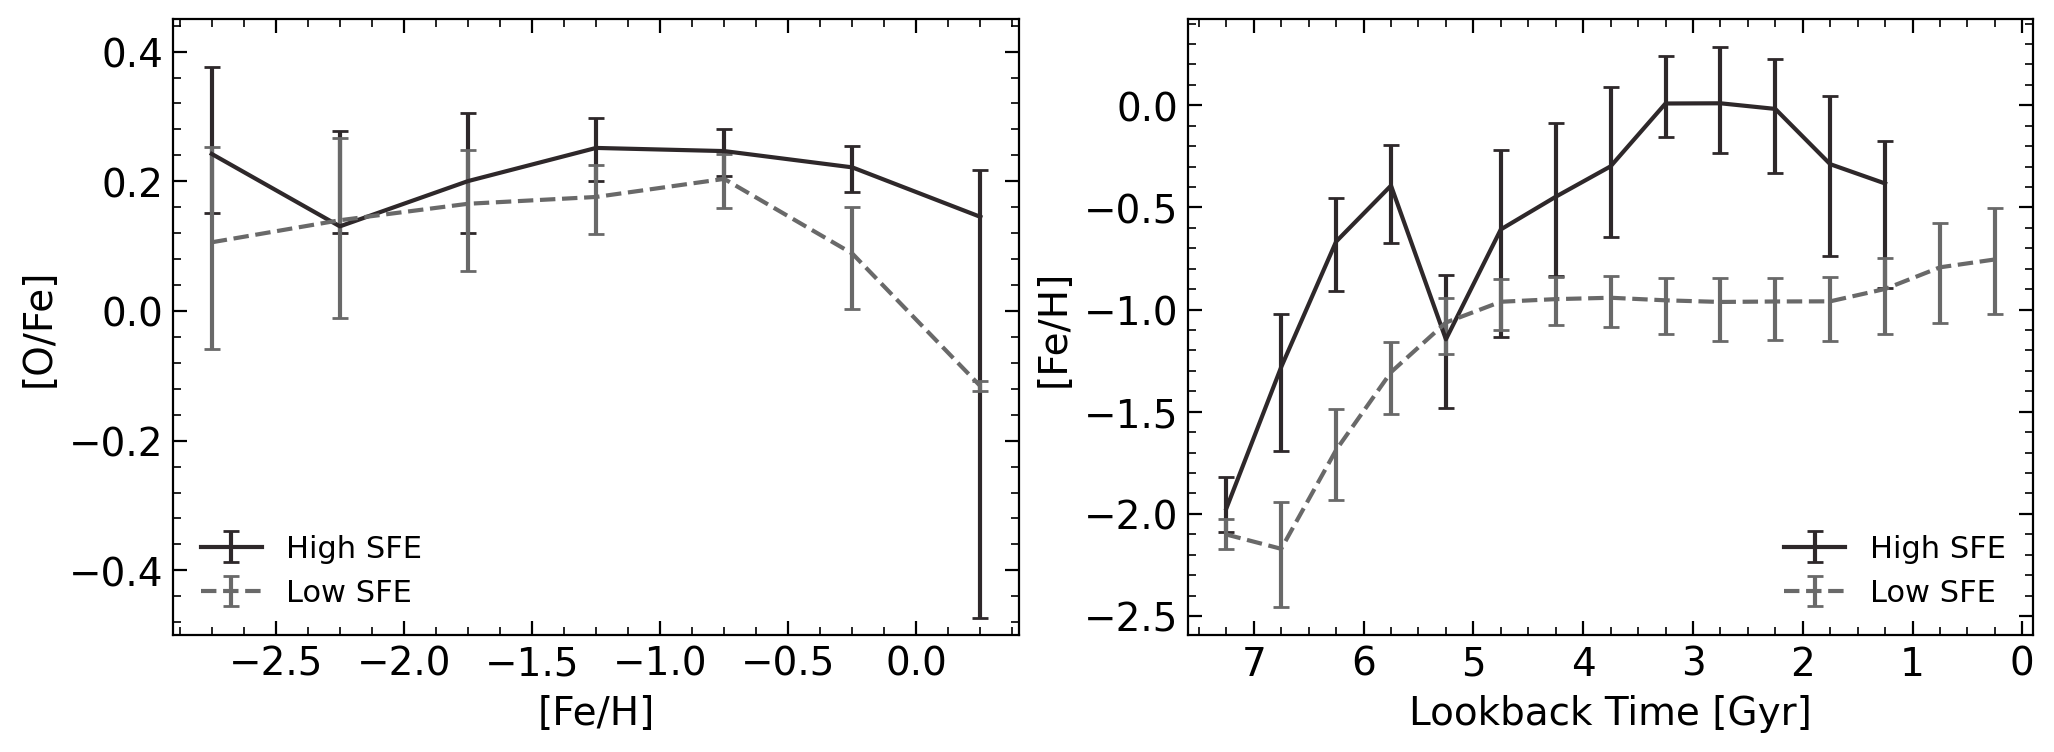

In [7]:
paths_pt2 = glob.glob('/home/amanda.ormazbal/gadget4/examples/CollidingGalaxiesSFR/output/Project3_snaps/*146')

fig, ax = plt.subplots(1, 2, figsize=(12,4), dpi=200)#, gridspec_kw = {"wspace":0, "hspace":0})
ax = np.ravel(ax)

df_highC = create_df(paths_pt2[0])

edges = np.arange(-3, 1, 0.5)#uni_bins(df["Fe_H"], 10)#np.arange(7.2, 11.3, 1)
x, y = func_bar(df_highC["Fe_H"] , df_highC["O_Fe"] , edges, reduce_func = np.median)
x, p = func_bar(df_highC["Fe_H"] , df_highC["O_Fe"] , edges, reduce_func = get_percentile)



p[:,0], p[:,1] = y - p[:,0], abs(y - p[:,1])
ax[0].errorbar(x, y, yerr = p.T, capsize = 3, c = "#2E282A", label = "High SFE", zorder = i)


ax[0].tick_params(bottom = True, top = True, left = True, right = True, direction = 'in', size = 5)
ax[0].tick_params(which ="minor",bottom = True, top = True, left = True, right = True, direction = 'in', size = 3)

ax[0].xaxis.set_major_locator(MultipleLocator(1))
ax[0].xaxis.set_minor_locator(MultipleLocator(1/4))
ax[0].yaxis.set_major_locator(MultipleLocator(0.25))
ax[0].yaxis.set_minor_locator(MultipleLocator(0.25/5))

ax[0].set_xlabel("[Fe/H]")
ax[0].set_ylabel("[O/Fe]")

ax[0].set_ylim(-0.5, 0.45)

edges = np.arange(0, 14, 0.5)#uni_bins(df["Fe_H"], 10)#np.arange(7.2, 11.3, 1)
x, y = func_bar(df_highC["Age"], df_highC["Fe_H"] , edges, reduce_func = np.median)
x, p = func_bar(df_highC["Age"], df_highC["Fe_H"] , edges, reduce_func = get_percentile)



p[:,0], p[:,1] = y - p[:,0], abs(y - p[:,1])
ax[1].errorbar(x, y, yerr = p.T, capsize = 3, c = "#2E282A", zorder = i, label = "High SFE")
ax[1].legend(fontsize = 11, loc='lower left', framealpha = 1, ncol = 2, edgecolor = "none")


ax[1].tick_params(bottom = True, top = True, left = True, right = True, direction = 'in', size = 5)
ax[1].tick_params(which ="minor",bottom = True, top = True, left = True, right = True, direction = 'in', size = 3)

ax[1].xaxis.set_major_locator(MultipleLocator(1))
ax[1].xaxis.set_minor_locator(MultipleLocator(1/4))
ax[1].yaxis.set_major_locator(MultipleLocator(0.5))
ax[1].yaxis.set_minor_locator(MultipleLocator(0.5/5))

ax[1].set_ylabel("[Fe/H]")
ax[1].set_xlabel("Age [Gyr]")





df_lowC = create_df(paths_pt2[1])

edges = np.arange(-3, 1, 0.5)#uni_bins(df["Fe_H"], 10)#np.arange(7.2, 11.3, 1)
x, y = func_bar(df_lowC["Fe_H"] , df_lowC["O_Fe"] , edges, reduce_func = np.median)
x, p = func_bar(df_lowC["Fe_H"] , df_lowC["O_Fe"] , edges, reduce_func = get_percentile)



p[:,0], p[:,1] = y - p[:,0], abs(y - p[:,1])
ax[0].errorbar(x, y, yerr = p.T, capsize = 3, c = "dimgray", label = "Low SFE", zorder = i, ls = "--")

ax[0].legend(fontsize = 11, loc='lower left', framealpha = 1, ncol = 1, edgecolor = "none")


ax[0].tick_params(bottom = True, top = True, left = True, right = True, direction = 'in', size = 5)
ax[0].tick_params(which ="minor",bottom = True, top = True, left = True, right = True, direction = 'in', size = 3)

ax[0].xaxis.set_major_locator(MultipleLocator(0.5))
ax[0].xaxis.set_minor_locator(MultipleLocator(0.5/4))
ax[0].yaxis.set_major_locator(MultipleLocator(0.2))
ax[0].yaxis.set_minor_locator(MultipleLocator(0.2/5))

ax[0].set_xlabel("[Fe/H]")
ax[0].set_ylabel("[O/Fe]")

ax[0].set_ylim(-0.5, 0.45)

edges = np.arange(0, 14, 0.5)#uni_bins(df["Fe_H"], 10)#np.arange(7.2, 11.3, 1)
x, y = func_bar(df_lowC["Age"], df_lowC["Fe_H"] , edges, reduce_func = np.median)
x, p = func_bar(df_lowC["Age"], df_lowC["Fe_H"] , edges, reduce_func = get_percentile)



p[:,0], p[:,1] = y - p[:,0], abs(y - p[:,1])
ax[1].errorbar(x, y, yerr = p.T, capsize = 3, c = "dimgray", zorder = i, ls = "--", label = "Low SFE")


ax[1].tick_params(bottom = True, top = True, left = True, right = True, direction = 'in', size = 5)
ax[1].tick_params(which ="minor",bottom = True, top = True, left = True, right = True, direction = 'in', size = 3)

ax[1].xaxis.set_major_locator(MultipleLocator(1))
ax[1].xaxis.set_minor_locator(MultipleLocator(1/4))
ax[1].yaxis.set_major_locator(MultipleLocator(0.5))
ax[1].yaxis.set_minor_locator(MultipleLocator(0.5/5))
ax[1].legend(fontsize = 11, loc='lower right', framealpha = 1, ncol = 1, edgecolor = "none")

ax[1].set_ylabel("[Fe/H]")
ax[1].set_xlabel("Lookback Time [Gyr]")
ax[1].invert_xaxis()

In [8]:
df_highC["Age"].sort_values()

87309    1.002911
48114    1.022052
60739    1.024445
56415    1.037604
45558    1.044782
           ...   
11626    7.084845
26432    7.084845
28197    7.086041
3106     7.086639
26966    7.086639
Name: Age, Length: 83509, dtype: float32

In [9]:
df_highC["Mass"]

2         104206.039062
3         104720.039062
4         113601.578125
5         220294.296875
6         198750.015625
              ...      
101061     85184.484375
101062     87298.820312
101064     86006.914062
101065     85184.484375
101066     86594.320312
Name: Mass, Length: 83509, dtype: float32

7.1637999877333645
7.1637999877333645


/tmp/ipykernel_2792189/698583637.py:27: RuntimeWarning: divide by zero encountered in log10
  Fe_H = np.log10((Fe/at_Fe)/H) - FeH_sun
/tmp/ipykernel_2792189/698583637.py:28: RuntimeWarning: invalid value encountered in divide
  O_Fe = np.log10((O/at_O)/(Fe/at_Fe)) - OFe_sun
/usr/local/python-3.11.4/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/python-3.11.4/lib/python3.11/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)
/tmp/ipykernel_2792189/698583637.py:27: RuntimeWarning: divide by zero encountered in log10
  Fe_H = np.log10((Fe/at_Fe)/H) - FeH_sun
/tmp/ipykernel_2792189/698583637.py:28: RuntimeWarning: invalid value encountered in divide
  O_Fe = np.log10((O/at_O)/(Fe/at_Fe)) - OFe_sun
/usr/local/python-3.11.4/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mea

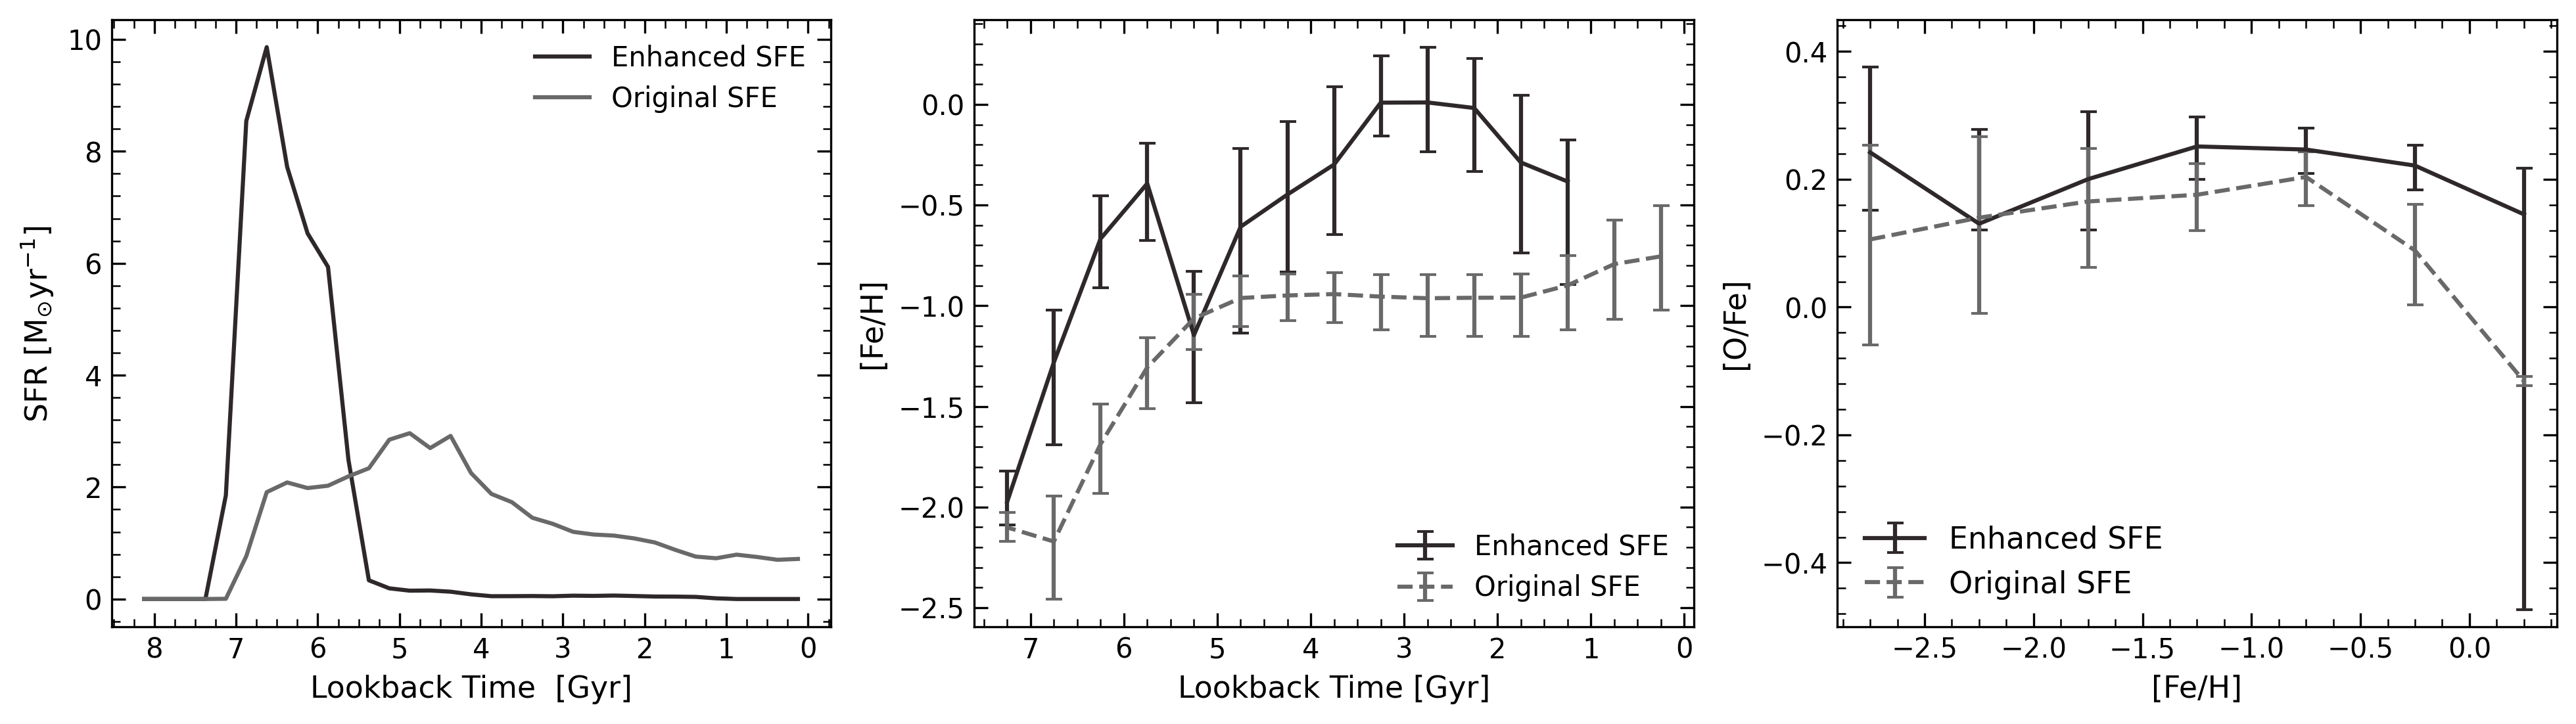

In [10]:
paths_pt2 = glob.glob('/home/amanda.ormazbal/gadget4/examples/CollidingGalaxiesSFR/output/Project3_snaps/*146')

fig, ax = plt.subplots(1, 3, figsize=(16,4), dpi=300)#, gridspec_kw = {"wspace":0, "hspace":0})
ax = np.ravel(ax)


df_highC = create_df(paths_pt2[0])




edges = np.arange(0, 8.5, 0.25)#uni_bins(df["Fe_H"], 10)#np.arange(7.2, 11.3, 1)
x, y = func_bar(df_highC["Age"], df_highC["Mass"] , edges, reduce_func = np.sum)

ax[0].plot(x, y/0.25e9, c = "#2E282A", label = "Enhanced SFE")
ax[0].legend(fontsize = 10, loc='upper left', framealpha = 1, ncol = 2, edgecolor = "none")


ax[0].tick_params(bottom = True, top = True, left = True, right = True, direction = 'in', size = 5, labelsize = 10)
ax[0].tick_params(which ="minor",bottom = True, top = True, left = True, right = True, direction = 'in', size = 3)

ax[0].xaxis.set_major_locator(MultipleLocator(1))
ax[0].xaxis.set_minor_locator(MultipleLocator(1/4))
ax[0].yaxis.set_major_locator(MultipleLocator(2))
ax[0].yaxis.set_minor_locator(MultipleLocator(2/5))

ax[0].set_ylabel(r"SFR [M$_{\odot}$yr$^{-1}$] ")
ax[0].set_xlabel("Age [Gyr]")

edges = np.arange(-3, 1, 0.5)#uni_bins(df["Fe_H"], 10)#np.arange(7.2, 11.3, 1)
x, y = func_bar(df_highC["Fe_H"] , df_highC["O_Fe"] , edges, reduce_func = np.median)
x, p = func_bar(df_highC["Fe_H"] , df_highC["O_Fe"] , edges, reduce_func = get_percentile)

p[:,0], p[:,1] = y - p[:,0], abs(y - p[:,1])
ax[2].errorbar(x, y, yerr = p.T, capsize = 3, c = "#2E282A", label = "Enhanced SFE", zorder = i)


ax[2].tick_params(bottom = True, top = True, left = True, right = True, direction = 'in', size = 5, labelsize = 10)
ax[2].tick_params(which ="minor",bottom = True, top = True, left = True, right = True, direction = 'in', size = 3)

ax[2].xaxis.set_major_locator(MultipleLocator(1))
ax[2].xaxis.set_minor_locator(MultipleLocator(1/4))
ax[2].yaxis.set_major_locator(MultipleLocator(0.25))
ax[2].yaxis.set_minor_locator(MultipleLocator(0.25/5))

ax[2].set_xlabel("[Fe/H]")
ax[2].set_ylabel("[O/Fe]")

ax[2].set_ylim(-0.5, 0.45)

edges = np.arange(0, 14, 0.5)#uni_bins(df["Fe_H"], 10)#np.arange(7.2, 11.3, 1)
x, y = func_bar(df_highC["Age"], df_highC["Fe_H"] , edges, reduce_func = np.median)
x, p = func_bar(df_highC["Age"], df_highC["Fe_H"] , edges, reduce_func = get_percentile)



p[:,0], p[:,1] = y - p[:,0], abs(y - p[:,1])
ax[1].errorbar(x, y, yerr = p.T, capsize = 3, c = "#2E282A", zorder = i, label = "Enhanced SFE")
ax[1].legend(fontsize = 10, loc='lower left', framealpha = 1, ncol = 2, edgecolor = "none")


ax[1].tick_params(bottom = True, top = True, left = True, right = True, direction = 'in', size = 5, labelsize = 10)
ax[1].tick_params(which ="minor",bottom = True, top = True, left = True, right = True, direction = 'in', size = 3)

ax[1].xaxis.set_major_locator(MultipleLocator(1))
ax[1].xaxis.set_minor_locator(MultipleLocator(1/4))
ax[1].yaxis.set_major_locator(MultipleLocator(0.5))
ax[1].yaxis.set_minor_locator(MultipleLocator(0.5/5))

ax[1].set_ylabel("[Fe/H]")
ax[1].set_xlabel("Age [Gyr]")





df_lowC = create_df(paths_pt2[1])
edges = np.arange(0, 8.5, 0.25)#uni_bins(df["Fe_H"], 10)#np.arange(7.2, 11.3, 1)
x, y = func_bar(df_lowC["Age"], df_lowC["Mass"] , edges, reduce_func = np.sum)

ax[0].plot(x, y/0.25e9, c = "dimgray", label = "Original SFE")
ax[0].legend(fontsize = 10, loc='upper right', framealpha = 1, ncol = 1, edgecolor = "none")


ax[0].tick_params(bottom = True, top = True, left = True, right = True, direction = 'in', size = 5, labelsize = 10)
ax[0].tick_params(which ="minor",bottom = True, top = True, left = True, right = True, direction = 'in', size = 3)

ax[0].xaxis.set_major_locator(MultipleLocator(1))
ax[0].xaxis.set_minor_locator(MultipleLocator(1/4))
ax[0].yaxis.set_major_locator(MultipleLocator(2))
ax[0].yaxis.set_minor_locator(MultipleLocator(2/5))

ax[0].set_ylabel(r"SFR [M$_{\odot}$yr$^{-1}$] ", fontsize = 11)
ax[0].set_xlabel("Lookback Time  [Gyr]", fontsize = 11)
ax[0].invert_xaxis()
edges = np.arange(-3, 1, 0.5)#uni_bins(df["Fe_H"], 10)#np.arange(7.2, 11.3, 1)
x, y = func_bar(df_lowC["Fe_H"] , df_lowC["O_Fe"] , edges, reduce_func = np.median)
x, p = func_bar(df_lowC["Fe_H"] , df_lowC["O_Fe"] , edges, reduce_func = get_percentile)



p[:,0], p[:,1] = y - p[:,0], abs(y - p[:,1])
ax[2].errorbar(x, y, yerr = p.T, capsize = 3, c = "dimgray", label = "Original SFE", zorder = i, ls = "--")

ax[2].legend(fontsize = 11, loc='lower left', framealpha = 1, ncol = 1, edgecolor = "none")


ax[2].tick_params(bottom = True, top = True, left = True, right = True, direction = 'in', size = 5, labelsize = 10)
ax[2].tick_params(which ="minor",bottom = True, top = True, left = True, right = True, direction = 'in', size = 3)

ax[2].xaxis.set_major_locator(MultipleLocator(0.5))
ax[2].xaxis.set_minor_locator(MultipleLocator(0.5/4))
ax[2].yaxis.set_major_locator(MultipleLocator(0.2))
ax[2].yaxis.set_minor_locator(MultipleLocator(0.2/5))

ax[2].set_xlabel("[Fe/H]", fontsize = 11)
ax[2].set_ylabel("[O/Fe]", fontsize = 11)

ax[2].set_ylim(-0.5, 0.45)

edges = np.arange(0, 14, 0.5)#uni_bins(df["Fe_H"], 10)#np.arange(7.2, 11.3, 1)
x, y = func_bar(df_lowC["Age"], df_lowC["Fe_H"] , edges, reduce_func = np.median)
x, p = func_bar(df_lowC["Age"], df_lowC["Fe_H"] , edges, reduce_func = get_percentile)



p[:,0], p[:,1] = y - p[:,0], abs(y - p[:,1])
ax[1].errorbar(x, y, yerr = p.T, capsize = 3, c = "dimgray", zorder = i, ls = "--", label = "Original SFE")


ax[1].tick_params(bottom = True, top = True, left = True, right = True, direction = 'in', size = 5, labelsize = 10)
ax[1].tick_params(which ="minor",bottom = True, top = True, left = True, right = True, direction = 'in', size = 3)

ax[1].xaxis.set_major_locator(MultipleLocator(1))
ax[1].xaxis.set_minor_locator(MultipleLocator(1/4))
ax[1].yaxis.set_major_locator(MultipleLocator(0.5))
ax[1].yaxis.set_minor_locator(MultipleLocator(0.5/5))
ax[1].legend(fontsize = 10, loc='lower right', framealpha = 1, ncol = 1, edgecolor = "none")

ax[1].set_ylabel("[Fe/H]", fontsize = 11)
ax[1].set_xlabel("Lookback Time [Gyr]", fontsize = 11)
ax[1].invert_xaxis()

In [19]:
edges = np.arange(0, 14, 0.5)#uni_bins(df["Fe_H"], 10)#np.arange(7.2, 11.3, 1)
x, y = func_bar(df_highC["Age"], df_highC["Fe_H"] , edges, reduce_func = len)
x,y

(array([ 0.25,  0.75,  1.25,  1.75,  2.25,  2.75,  3.25,  3.75,  4.25,
         4.75,  5.25,  5.75,  6.25,  6.75,  7.25,  7.75,  8.25,  8.75,
         9.25,  9.75, 10.25, 10.75, 11.25, 11.75, 12.25, 12.75, 13.25]),
 array([    0,     0,    76,   151,   219,   244,   218,   218,   411,
          561,   983, 15770, 26854, 34349,  3455,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0]))

In [21]:
edges = np.arange(0, 14, 0.5)#uni_bins(df["Fe_H"], 10)#np.arange(7.2, 11.3, 1)
x, y = func_bar(df_highC["Age"], df_highC["Fe_H"] , edges, reduce_func = np.median)
x,y

/usr/local/python-3.11.4/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/python-3.11.4/lib/python3.11/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)


(array([ 0.25,  0.75,  1.25,  1.75,  2.25,  2.75,  3.25,  3.75,  4.25,
         4.75,  5.25,  5.75,  6.25,  6.75,  7.25,  7.75,  8.25,  8.75,
         9.25,  9.75, 10.25, 10.75, 11.25, 11.75, 12.25, 12.75, 13.25]),
 array([        nan,         nan, -0.38301063, -0.28841782, -0.01796675,
         0.00958133,  0.00854516, -0.29897594, -0.44791317, -0.6078105 ,
        -1.1457376 , -0.39328718, -0.66728973, -1.2814684 , -1.974155  ,
                nan,         nan,         nan,         nan,         nan,
                nan,         nan,         nan,         nan,         nan,
                nan,         nan], dtype=float32))

## EXTRA

In [11]:
def add_scalebar(ax, l, units='kpc', loc='lower right', size=16, color='k'): #original size=16
    scalebar = AnchoredSizeBar(
                        ax.transData,
                        l,
                        f'{l} {units}',
                        loc,
                        pad=0.5,
                        color=color,
                        frameon=False,
                        size_vertical=l / 60,
                        fontproperties=fm.FontProperties(size=size),
                        sep=6)
    ax.add_artist(scalebar)
    ax.set(yticks=[], xticks=[])

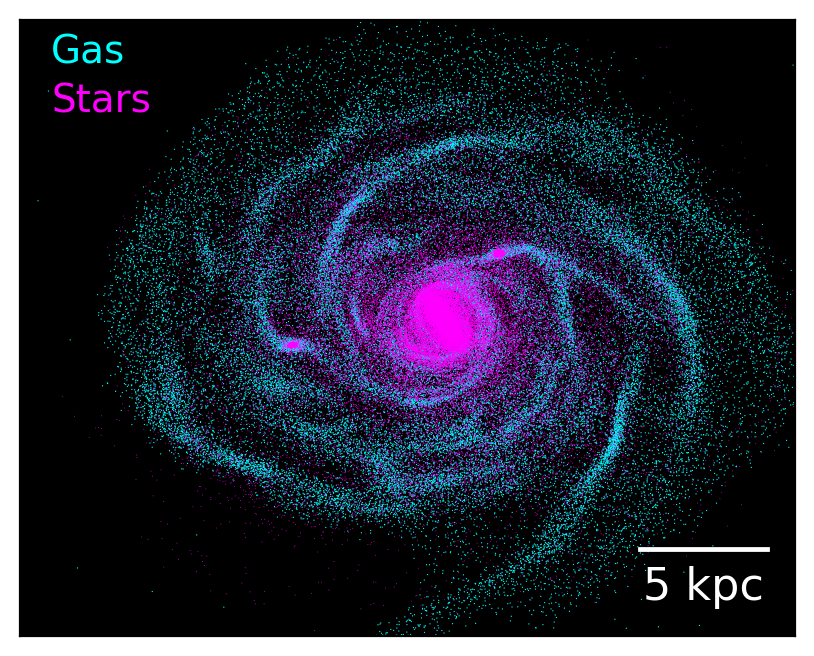

In [12]:
fig, ax = plt.subplots(1, 1, figsize=(5, 4), dpi=200, sharey = True,sharex = True,
                      gridspec_kw = {"wspace":0, "hspace":0})

header, data, info = read(paths_pt1[1], header_only = False, IC_only = False, control = False)
ax.scatter(data['PartType4']['Coordinates'][:,0], data['PartType4']['Coordinates'][:,1], s = 0.1, c = "magenta", zorder = 1, ec = "none")
ax.scatter(data['PartType0']['Coordinates'][:,0], data['PartType0']['Coordinates'][:,1], s = 0.2, c = "cyan", zorder = 0, ec = "none")

ax.set_xlim(-15,15)
ax.set_ylim(-15,15)
add_scalebar(ax, 5, units='kpc', loc='lower right', size=16, color='w')
ax.text(0.04,.9+0.03 , r'Gas', color = "cyan",
                  fontsize = 14, transform = ax.transAxes,
                  bbox=dict(facecolor = 'white', edgecolor = None, boxstyle='square', linewidth = 0, alpha=0))
ax.text(0.04,.82+0.03 , r'Stars', color = "magenta",
                  fontsize = 14, transform = ax.transAxes,
                  bbox=dict(facecolor = 'white', edgecolor = None, boxstyle='square', linewidth = 0, alpha=0))

ax.set_facecolor("k")

In [13]:
masses = []
for path in paths_pt1:
    df = create_df(path)
    mass = np.log10(np.sum(df["Mass"]))
    print(mass)
    masses.append(mass)
    

np.mean(masses)

11.622799970209599
10.111692
11.622799970209599
10.109292
11.622799970209599
10.115225
11.622799970209599
10.093033


/tmp/ipykernel_2792189/698583637.py:27: RuntimeWarning: divide by zero encountered in log10
  Fe_H = np.log10((Fe/at_Fe)/H) - FeH_sun
/tmp/ipykernel_2792189/698583637.py:28: RuntimeWarning: invalid value encountered in divide
  O_Fe = np.log10((O/at_O)/(Fe/at_Fe)) - OFe_sun
/tmp/ipykernel_2792189/698583637.py:27: RuntimeWarning: divide by zero encountered in log10
  Fe_H = np.log10((Fe/at_Fe)/H) - FeH_sun
/tmp/ipykernel_2792189/698583637.py:28: RuntimeWarning: invalid value encountered in divide
  O_Fe = np.log10((O/at_O)/(Fe/at_Fe)) - OFe_sun
/tmp/ipykernel_2792189/698583637.py:27: RuntimeWarning: divide by zero encountered in log10
  Fe_H = np.log10((Fe/at_Fe)/H) - FeH_sun
/tmp/ipykernel_2792189/698583637.py:28: RuntimeWarning: invalid value encountered in divide
  O_Fe = np.log10((O/at_O)/(Fe/at_Fe)) - OFe_sun
/tmp/ipykernel_2792189/698583637.py:27: RuntimeWarning: divide by zero encountered in log10
  Fe_H = np.log10((Fe/at_Fe)/H) - FeH_sun
/tmp/ipykernel_2792189/698583637.py:28: R

10.107311

In [14]:
header, data, info = read(paths_pt2[0], header_only = False, IC_only = False, control = False)

In [15]:
header

{'npart': array([ 68900, 200000,  60000,  40000, 101068,      1], dtype=int32),
 'massarr': array([0.00000000e+00, 4.50166503e-04, 3.25403592e-05, 3.25482958e-05,
        0.00000000e+00, 0.00000000e+00]),
 'time': 0.7309999987483025,
 'redshift': 0.0,
 'flag_sfr': 1,
 'flag_feedback': 1,
 'npartTotal': array([ 68900, 200000,  60000,  40000, 101068,      1], dtype=uint32),
 'flag_cooling': 1,
 'num_files': 1,
 'BoxSize': 10000.0,
 'Omega0': 0.28,
 'OmegaLambda': 0.72,
 'HubbleParam': 0.7,
 'flag_stellarage': 1,
 'flag_metals': 1,
 'npartTotalHighWord': array([0, 0, 0, 0, 0, 0], dtype=uint32),
 'flag_entropy_instead_u': 0,
 'flag_doubleprecision': 0,
 'flag_ic_info': 0,
 'lpt_scalingfactor': 0.0,
 'fill': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=int8),
 'names': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0], dtype=int8)}

In [16]:
header, data, info = read(paths_pt2[1], header_only = False, IC_only = False, control = False)
header

{'npart': array([ 78573, 200000,  60000,  40000,  73162,      1], dtype=int32),
 'massarr': array([0.00000000e+00, 4.50166503e-04, 3.25403592e-05, 3.25482958e-05,
        0.00000000e+00, 0.00000000e+00]),
 'time': 0.7309999987483025,
 'redshift': 0.0,
 'flag_sfr': 1,
 'flag_feedback': 1,
 'npartTotal': array([ 78573, 200000,  60000,  40000,  73162,      1], dtype=uint32),
 'flag_cooling': 1,
 'num_files': 1,
 'BoxSize': 10000.0,
 'Omega0': 0.28,
 'OmegaLambda': 0.72,
 'HubbleParam': 0.7,
 'flag_stellarage': 1,
 'flag_metals': 1,
 'npartTotalHighWord': array([0, 0, 0, 0, 0, 0], dtype=uint32),
 'flag_entropy_instead_u': 0,
 'flag_doubleprecision': 0,
 'flag_ic_info': 0,
 'lpt_scalingfactor': 0.0,
 'fill': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=int8),
 'names': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0], dtype=int8)}